# 01 · Exploratory analysis

**Question.** Which attacks happen on which capture day, and how do the days differ?

This decides what any split can measure: a split that holds out a day also holds out whatever
attacks happened that day.

Finding: in CIC-IDS2017 every attack family appears on exactly one capture day (8 of 8 families), so holding out a day holds out its attack types. In CSE-CIC-IDS2018, 4 families repeat on later days.


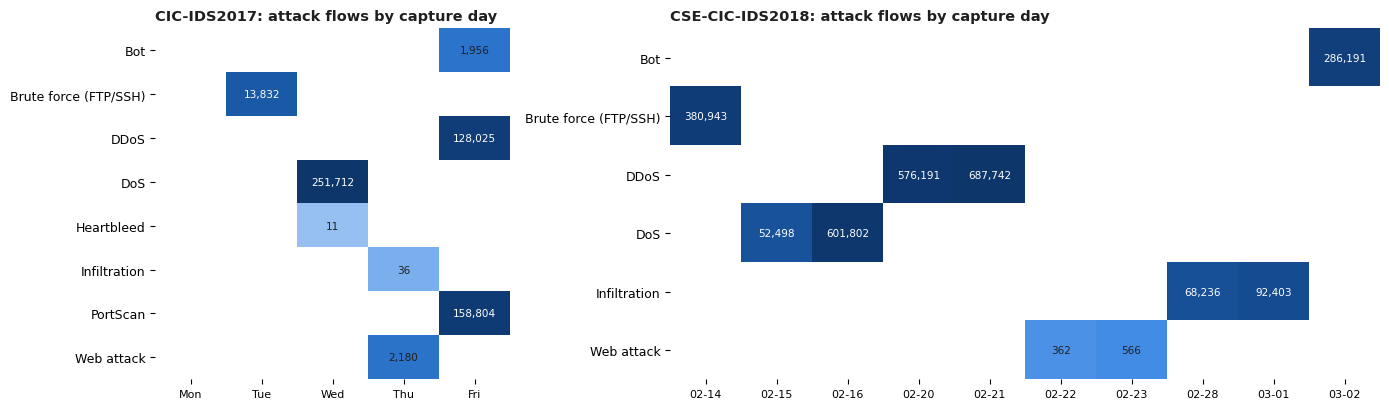

In [1]:
import sys, json, warnings
sys.path.insert(0, "..")  # make src/ importable from notebooks/
warnings.filterwarnings("ignore", message="X does not have valid feature names")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.reporting.plots import load_summary, recall_dots, recall_table, style, COLORS, NAMES, INK, MUTED
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)
REPORTS = "../reports"

from src.evaluation.folds import day_key
from src.models.cross_dataset import FAMILY
counts = {}
for year in ["2017", "2018"]:
    d = pd.read_parquet(f"../data/processed/cicids{year}_eval.parquet", columns=["Label", "Meta_source"])
    d["day"] = d["Meta_source"].map(lambda s: day_key(s, year))
    d["family"] = d["Label"].map(FAMILY)
    counts[year] = d.groupby(["family", "day"]).size().unstack(fill_value=0)
order17 = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
c17 = counts["2017"][order17]
attacks17 = c17.drop(index="Benign")
one_day = (attacks17 > 0).sum(axis=1)
print(f"Finding: in CIC-IDS2017 every attack family appears on exactly one capture day "
      f"({(one_day == 1).sum()} of {len(one_day)} families), so holding out a day holds out its attack types. "
      f"In CSE-CIC-IDS2018, {((counts['2018'].drop(index='Benign') > 0).sum(axis=1) > 1).sum()} families repeat on later days.")

from matplotlib.colors import LinearSegmentedColormap, LogNorm
blues = LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [5, 10]})
for ax, (year, table) in zip(axes, [("2017", attacks17), ("2018", counts["2018"].drop(index="Benign"))]):
    shown = table.replace(0, np.nan)
    ax.imshow(shown, cmap=blues, norm=LogNorm(vmin=1, vmax=table.values.max()), aspect="auto")
    for (i, j), v in np.ndenumerate(table.values):
        if v:
            ax.text(j, i, f"{v:,}", ha="center", va="center", fontsize=7.5,
                    color="white" if v > 5000 else INK)
    ax.set_xticks(range(table.shape[1]))
    ax.set_xticklabels([c[5:] if year == "2018" else c[:3] for c in table.columns], rotation=0, fontsize=8)
    ax.set_yticks(range(table.shape[0])); ax.set_yticklabels(table.index, fontsize=9)
    ax.set_title(f"{'CIC-IDS2017' if year == '2017' else 'CSE-CIC-IDS2018'}: attack flows by capture day",
                 loc="left", fontweight="bold", color=INK, fontsize=10.5)
    for s in ax.spines.values(): s.set_visible(False)
fig.tight_layout(); plt.show()

In [2]:
share = pd.DataFrame({"2017 flows": c17.sum(), "2017 attack share": (attacks17.sum() / c17.sum()).round(4)})
share

,2017 flows,2017 attack share
day,,
Monday,529443,0.0000
Tuesday,445617,0.0310
Wednesday,691384,0.3641
Thursday,458611,0.0048
Friday,702671,0.4110


## What this means for evaluation

- **CIC-IDS2017:** each attack family sits on a single day, and Monday has no attacks at all.
  Training on earlier days and testing on a later day therefore always tests attack types the
  model has never seen. 2017 can measure unseen-attack detection, but not "the same attack later".
- **CSE-CIC-IDS2018:** some families repeat (DoS, DDoS, web attacks, infiltration). That lets
  `04_forward_2018` separate three questions: the same attack on a later date, the same family with a
  new tool, and a brand-new family.
- **Imbalance differs by day.** The attack share of a test day sets the no-skill baseline for
  average precision, so average precision is never compared across days without its prevalence.

## Limits

The 2018 benign counts are a 10% sample; the attack counts are complete. The heatmap uses a log
color scale, so small classes stay visible; read the printed counts, not the shade.